
cu_R1s(r) =
+307.0613 * exp(-29.6964 r)
+208.4625 * r * exp(-25.2508 r)
-0.0851 * r * exp(-12.5550 r)
+986.5094 * r^2 * exp(-36.3548 r)
-0.0953 * r^2 * exp(-9.2482 r)
-0.0150 * r^2 * exp(-6.2646 r)
+0.0006 * r^2 * exp(-4.1881 r)
+7.3934 * r^3 * exp(-14.8890 r)
-0.0000 * r^3 * exp(-2.4698 r)
-0.0000 * r^3 * exp(-1.4684 r)
-0.0000 * r^3 * exp(-0.9292 r)

cu_R2s(r) =
+94.4446 * exp(-29.6964 r)
+729.5615 * r * exp(-25.2508 r)
-665.9803 * r * exp(-12.5550 r)
+23.0870 * r^2 * exp(-36.3548 r)
-86.6827 * r^2 * exp(-9.2482 r)
+1.5020 * r^2 * exp(-6.2646 r)
-0.1696 * r^2 * exp(-4.1881 r)
-1667.6662 * r^3 * exp(-14.8890 r)
+0.0018 * r^3 * exp(-2.4698 r)
-0.0001 * r^3 * exp(-1.4684 r)
+0.0000 * r^3 * exp(-0.9292 r)

cu_R3s(r) =
-35.3311 * exp(-29.6964 r)
-323.0731 * r * exp(-25.2508 r)
+300.0849 * r * exp(-12.5550 r)
-101.5093 * r^2 * exp(-36.3548 r)
+46.5179 * r^2 * exp(-9.2482 r)
-177.6614 * r^2 * exp(-6.2646 r)
-31.6628 * r^2 * exp(-4.1881 r)
+2439.7022 * r^3 * exp(-14.8890 r)
-0.0452 * r^3 * 

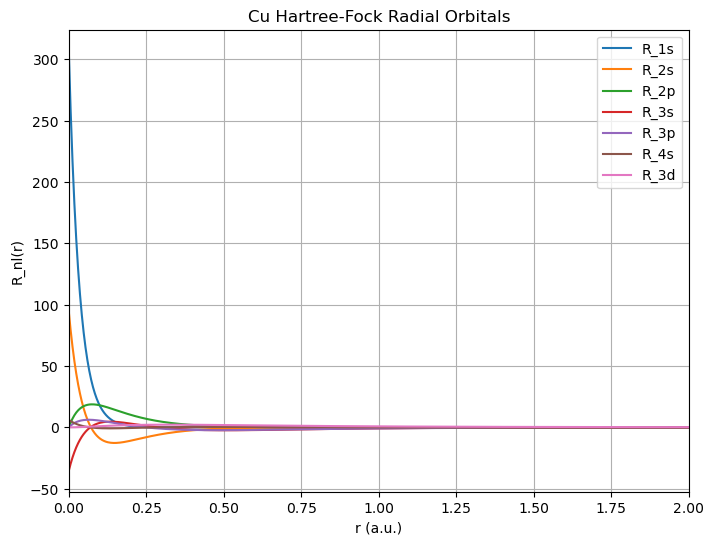

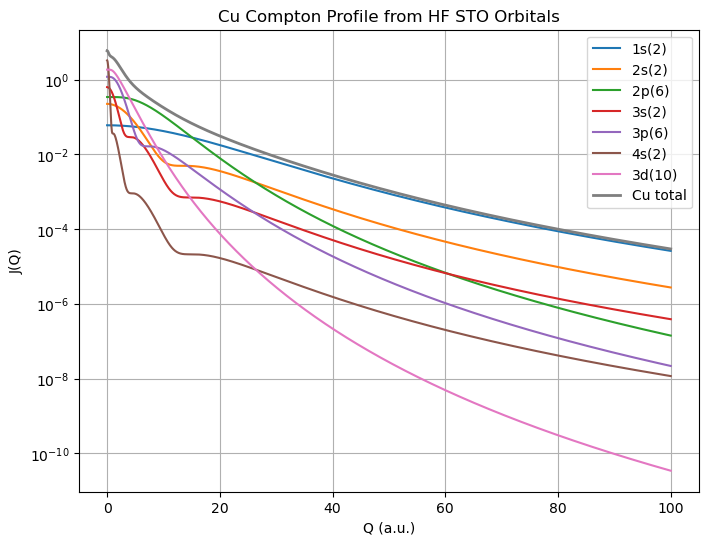

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Copper Hartree-Fock STO data
# Cu: 1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(1) 
# Ground term: 4S
# Format: (n_j, Z_j, C_j)
# =====================================================

copper_1s = [
    (1, 29.6964,  0.948723),
    (2, 25.2508,  0.056347),
    (2, 12.5550, -0.000132),
    (3, 36.3548,  0.008076),
    (3,  9.2482, -0.000094),
    (3,  6.2646, -0.000058),
    (3,  4.1881,  0.000009),
    (4, 14.8890,  0.000346),
    (4,  2.4698, -0.000004),
    (4,  1.4684, -0.000003),
    (4,  0.9292, -0.000001),
]


# =====================================================
# 2s orbital
# =====================================================

copper_2s = [
    (1, 29.6964,  0.291804),
    (2, 25.2508,  0.197199),
    (2, 12.5550, -1.032643),
    (3, 36.3548,  0.000189),
    (3,  9.2482, -0.085466),
    (3,  6.2646,  0.005789),
    (3,  4.1881, -0.002676),
    (4, 14.8890, -0.078044),
    (4,  2.4698,  0.000278),
    (4,  1.4684, -0.000149),
    (4,  0.9292,  0.000054),
]


# =====================================================
# 3s orbital
# =====================================================

copper_3s = [
    (1, 29.6964, -0.109162),
    (2, 25.2508, -0.087326),
    (2, 12.5550,  0.465300),
    (3, 36.3548, -0.000831),
    (3,  9.2482,  0.045865),
    (3,  6.2646, -0.684743),
    (3,  4.1881, -0.499518),
    (4, 14.8890,  0.114174),
    (4,  2.4698, -0.006857),
    (4,  1.4684,  0.000964),
    (4,  0.9292, -0.000379),
]


# =====================================================
# 4s orbital
# =====================================================

copper_4s = [
    (1, 29.6964,  0.018928),
    (2, 25.2508,  0.015368),
    (2, 12.5550, -0.082080),
    (3, 36.3548,  0.000180),
    (3,  9.2482, -0.014992),
    (3,  6.2646,  0.155119),
    (3,  4.1881,  0.077800),
    (4, 14.8890, -0.020952),
    (4,  2.4698, -0.229694),
    (4,  1.4684, -0.534263),
    (4,  0.9292, -0.370075),
]


# =====================================================
# 2p orbital
# =====================================================

copper_2p = [
    (2, 48.7948,  0.000433),
    (2, 18.4738,  0.318485),
    (2,  9.9976,  0.440209),
    (2,  4.7454,  0.007102),
    (3, 15.1401,  0.284462),
    (3,  3.8217, -0.000579),
    (3,  2.5167,  0.000353),
]


# =====================================================
# 3p orbital
# =====================================================

copper_3p = [
    (2, 48.7948,  0.000109),
    (2, 18.4738,  0.067352),
    (2,  9.9976,  0.525020),
    (2,  4.7454, -0.832540),
    (3, 15.1401, -0.022690),
    (3,  3.8217, -0.397454),
    (3,  2.5167, -0.053274),
]


# =====================================================
# 3d orbital
# =====================================================

copper_3d = [
    (3, 14.1915,  0.018641),
    (3,  7.5450,  0.239705),
    (3,  4.4604,  0.427410),
    (3,  2.5096,  0.365471),
    (3,  1.4098,  0.148151),
]

# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapezoid(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Copper radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, copper_1s)
R2s = R_nl(r, copper_2s)
R3s = R_nl(r, copper_3s)
R4s = R_nl(r, copper_4s)
R2p = R_nl(r, copper_2p)
R3p = R_nl(r, copper_3p)
R3d = R_nl(r, copper_3d)

print_R_formula(copper_1s, "cu_R1s")
print_R_formula(copper_2s, "cu_R2s")
print_R_formula(copper_3s, "cu_R3s")
print_R_formula(copper_4s, "cu_R4s")
print_R_formula(copper_2p, "cu_R2p")
print_R_formula(copper_3p, "cu_R3p")
print_R_formula(copper_3d, "cu_R3d")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))


# Copper has  1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(1) 
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 10*J_3d + J_4s 

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s(2)": J_1s,
    "J_2s(2)": J_2s,
    "J_2p(6)": J_2p,
    "J_3s(2)": J_3s,
    "J_3p(6)": J_3p,
    "J_3d(10)":J_3d,
    "J_4s(1)": J_4s,
    "J_total_Cu": J_total
    })
print(table)
table.to_csv("Cu__STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Cu Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 10*J_3d, label="3d(10)")
plt.plot(Q, J_total, label="Cu total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Cu Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()